In [5]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

pd_runs = Path("..") / "pd_runs"
experiment_dirs = sorted([p for p in pd_runs.iterdir() if p.is_dir()])
experiment_dirs


[WindowsPath('../pd_runs/hs_ws_runs'),
 WindowsPath('../pd_runs/noise_runs'),
 WindowsPath('../pd_runs/small_runs')]

In [6]:
def load_scalars(run_dir: Path, tag: str) -> pd.DataFrame:
    event_files = sorted(run_dir.glob("events.out.tfevents*"))
    if not event_files:
        return pd.DataFrame()

    ea = EventAccumulator(str(event_files[0]), size_guidance={"scalars": 0})
    ea.Reload()
    if tag not in ea.Tags().get("scalars", []):
        return pd.DataFrame()

    scalars = ea.Scalars(tag)
    if not scalars:
        return pd.DataFrame()

    df = pd.DataFrame([{"step": s.step, "value": s.value} for s in scalars])
    df["run"] = run_dir.name
    df["tag"] = tag
    return df


def parse_run_meta(run_name: str) -> dict:
    meta = {}
    h = re.search(r"_h(\d+)_", run_name)
    ws = re.search(r"_ws([\d.]+)_", run_name)
    n = re.search(r"_n([\d.]+)_", run_name)
    seed = re.search(r"_seed(\d+)_", run_name)
    if h:
        meta["hidden_size"] = int(h.group(1))
    if ws:
        meta["ws"] = float(ws.group(1))
    if n:
        meta["noise"] = float(n.group(1))
    if seed:
        meta["seed"] = int(seed.group(1))
    return meta


def run_label(meta: dict, omit_keys=()) -> str:
    parts = []
    if "hidden_size" in meta and "hidden_size" not in omit_keys:
        parts.append(f"h={meta['hidden_size']}")
    if "ws" in meta and "ws" not in omit_keys:
        parts.append(f"ws={meta['ws']}")
    if "noise" in meta and "noise" not in omit_keys:
        parts.append(f"noise={meta['noise']}")
    if "seed" in meta and "seed" not in omit_keys:
        parts.append(f"seed={meta['seed']}")
    return ", ".join(parts) if parts else "unknown"


def style_maps(run_dirs):
    """Pick color/linestyle encodings from whatever varies in this run set."""
    metas = [parse_run_meta(p.name) for p in run_dirs]
    hidden_sizes = sorted({m["hidden_size"] for m in metas if "hidden_size" in m})
    secondary_key = "ws" if any("ws" in m for m in metas) else "noise"
    secondary_vals = sorted({m[secondary_key] for m in metas if secondary_key in m})
    seeds = sorted({m["seed"] for m in metas if "seed" in m})

    # Single hs (e.g. noise split): color by noise/ws, linestyle by seed
    if len(hidden_sizes) <= 1:
        colors = {v: plt.cm.tab10(i % 10) for i, v in enumerate(secondary_vals)}
        ls_cycle = ["-", "--", ":", "-."]
        linestyles = {s: ls_cycle[i % len(ls_cycle)] for i, s in enumerate(seeds)}
        return colors, linestyles, secondary_key, "by_secondary"

    colors = {hs: plt.cm.tab10(i % 10) for i, hs in enumerate(hidden_sizes)}
    ls_cycle = ["-", "--", ":", "-."]
    linestyles = {v: ls_cycle[i % len(ls_cycle)] for i, v in enumerate(secondary_vals)}
    return colors, linestyles, secondary_key, "by_hs"


def plot_experiment_losses(
    exp_dir: Path,
    run_dirs=None,
    title=None,
    omit_label_keys=(),
    tags=("train/loss", "valid/loss"),
):
    if run_dirs is None:
        run_dirs = sorted([p for p in exp_dir.iterdir() if p.is_dir()])
    else:
        run_dirs = sorted(run_dirs)
    if not run_dirs:
        print(f"No runs in {exp_dir}")
        return

    colors, linestyles, secondary_key, mode = style_maps(run_dirs)
    fig, axes = plt.subplots(len(tags), 1, figsize=(12, 5 * len(tags)), sharex=True)
    if len(tags) == 1:
        axes = [axes]

    for ax, tag in zip(axes, tags):
        for run_dir in run_dirs:
            meta = parse_run_meta(run_dir.name)
            df = load_scalars(run_dir, tag)
            if df.empty:
                continue
            if mode == "by_secondary":
                color = colors.get(meta.get(secondary_key), "C0")
                ls = linestyles.get(meta.get("seed"), "-")
            else:
                color = colors.get(meta.get("hidden_size"), "C0")
                ls = linestyles.get(meta.get(secondary_key), "-")
            ax.plot(
                df["step"],
                df["value"],
                color=color,
                linestyle=ls,
                alpha=0.85,
                label=run_label(meta, omit_keys=omit_label_keys),
                linewidth=1.5,
            )
        ax.set_yscale("log")
        ax.set_ylabel("loss")
        ax.set_title(tag)
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel("step")
    handles, labels = axes[0].get_legend_handles_labels()
    seen = {}
    for h, lab in zip(handles, labels):
        if lab not in seen:
            seen[lab] = h
    ncol = 2 if len(seen) > 12 else 1
    axes[0].legend(
        seen.values(),
        seen.keys(),
        fontsize=8,
        ncol=ncol,
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        borderaxespad=0,
    )
    fig.suptitle(
        title or f"{exp_dir.name} loss curves ({len(run_dirs)} runs)",
        fontsize=14,
    )
    fig.tight_layout()
    plt.show()


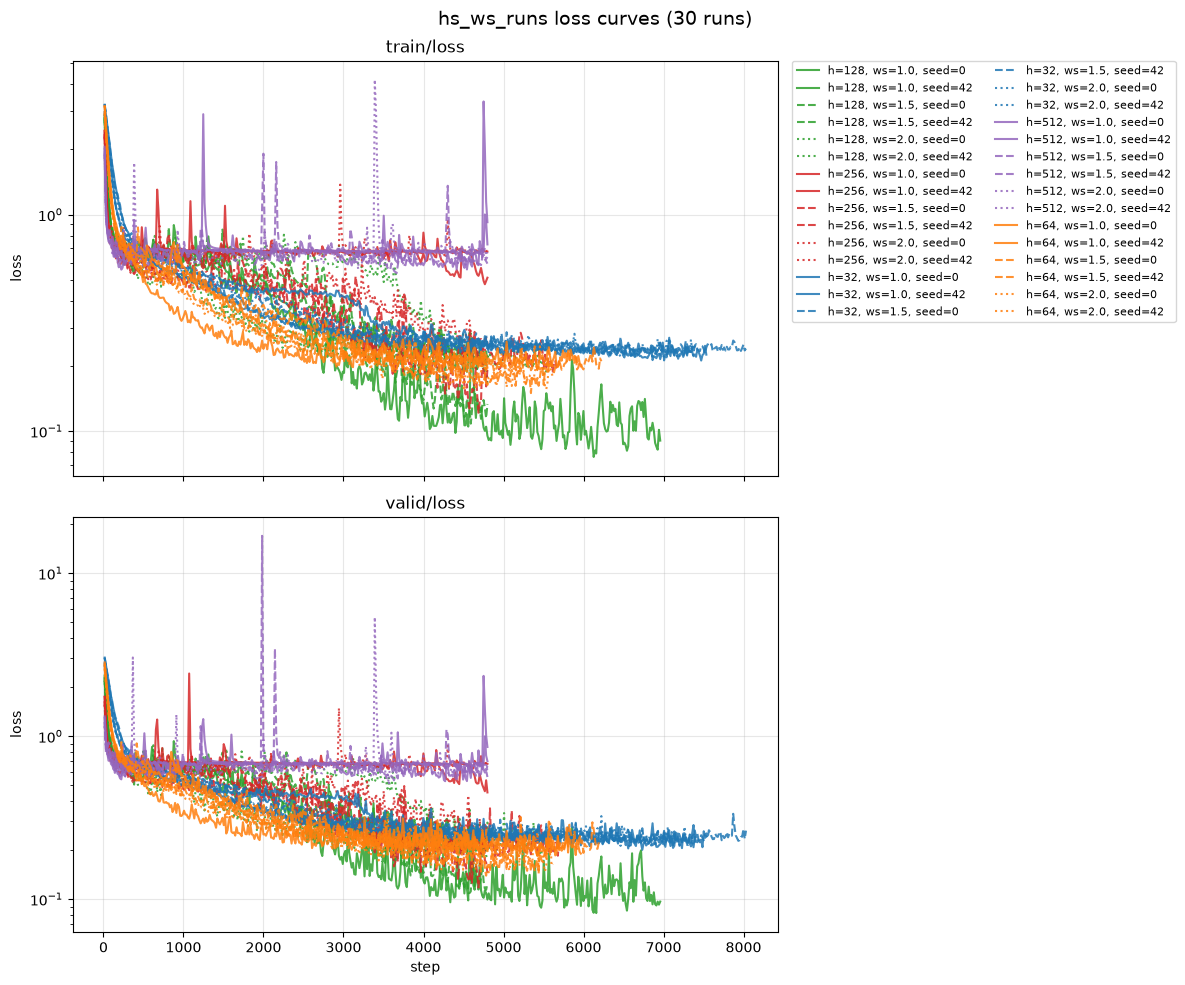

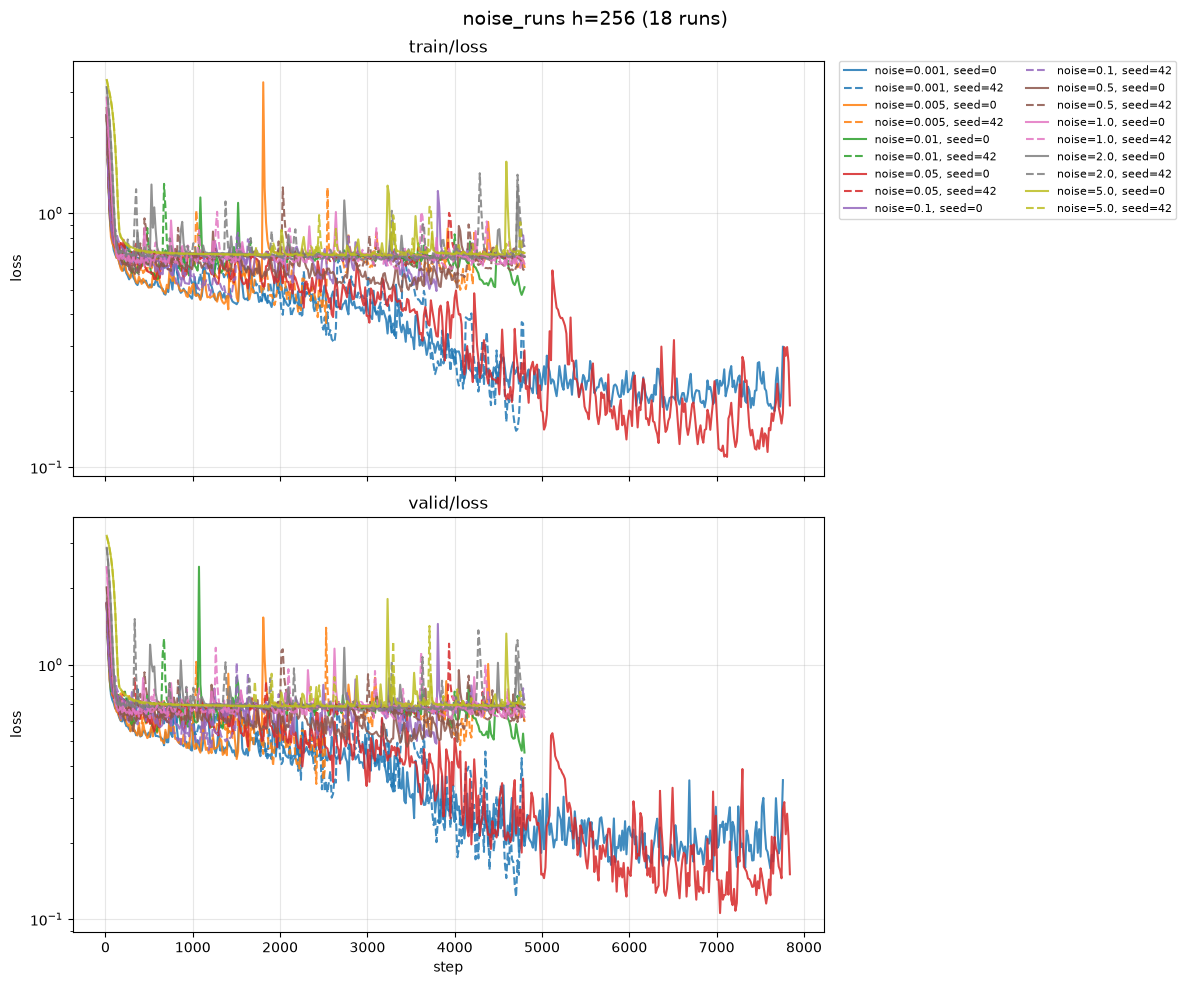

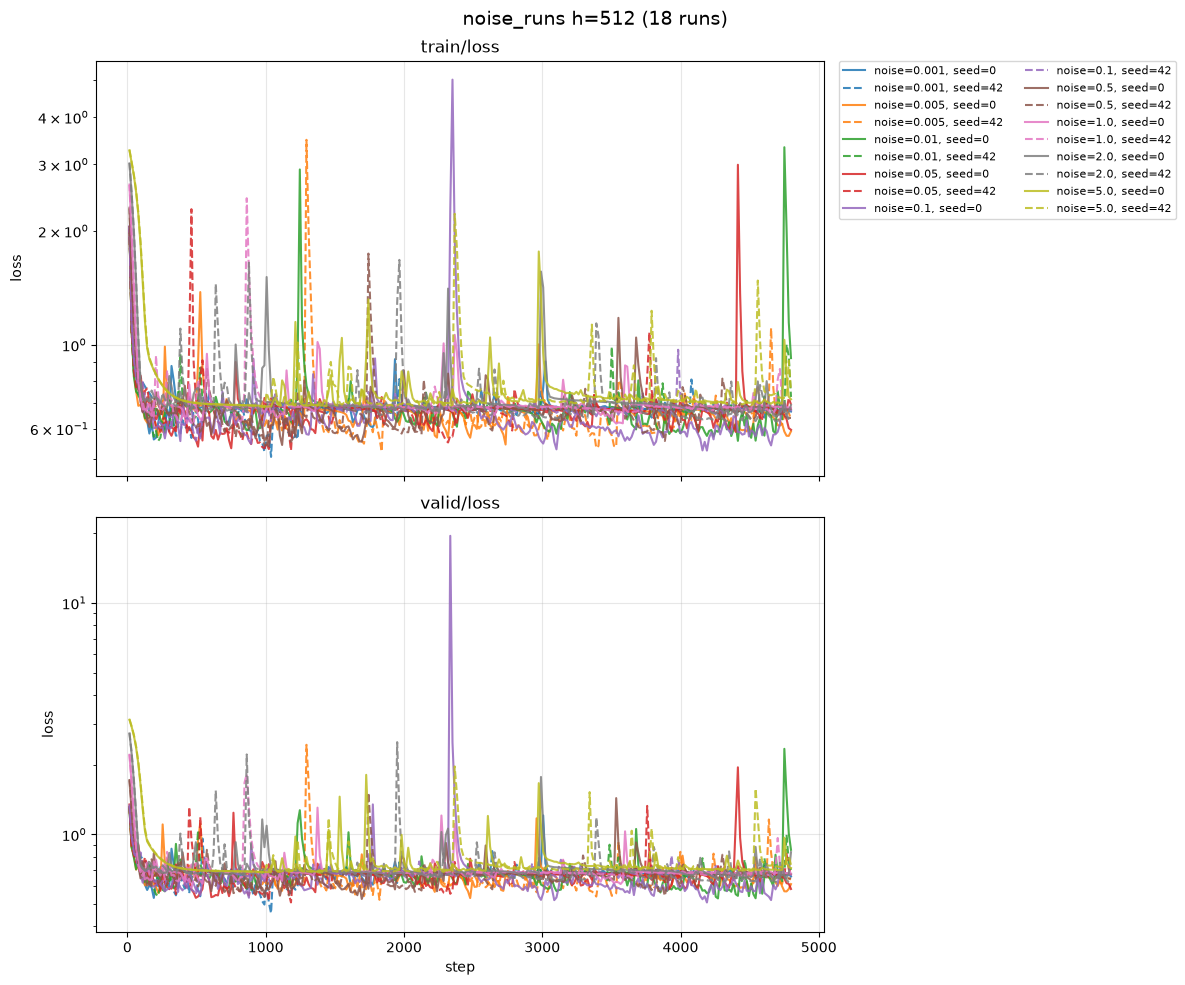

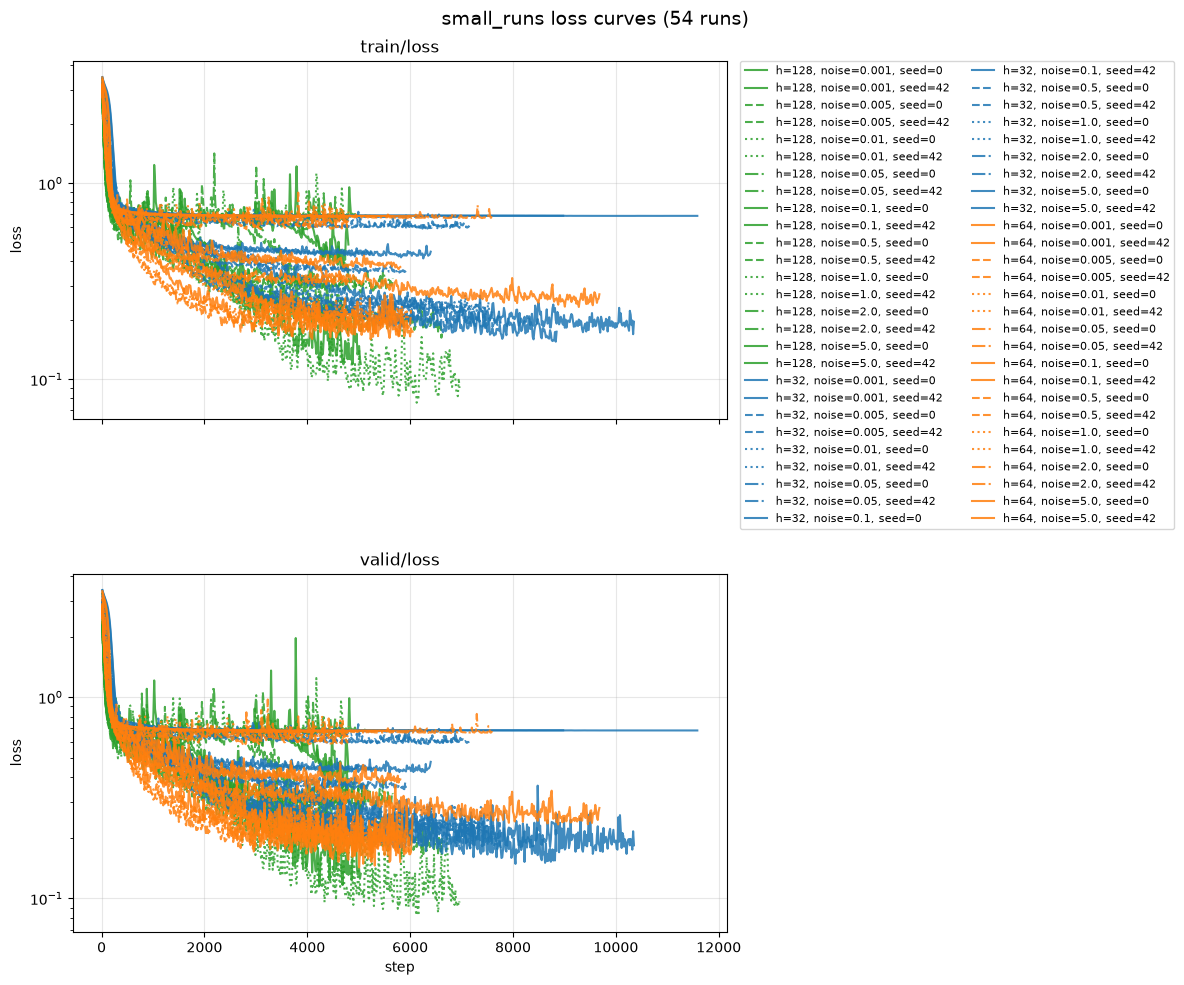

In [7]:
for exp_dir in experiment_dirs:
    run_dirs = sorted([p for p in exp_dir.iterdir() if p.is_dir()])
    if exp_dir.name == "noise_runs":
        by_hs = {}
        for run_dir in run_dirs:
            hs = parse_run_meta(run_dir.name).get("hidden_size")
            by_hs.setdefault(hs, []).append(run_dir)
        for hs in sorted(by_hs):
            plot_experiment_losses(
                exp_dir,
                run_dirs=by_hs[hs],
                title=f"noise_runs h={hs} ({len(by_hs[hs])} runs)",
                omit_label_keys=("hidden_size",),
            )
    else:
        plot_experiment_losses(exp_dir)
